In [1]:
import json
import pandas as pd
from utils.data_loader import load_dict
pth= "bbox_beh_include_crossing_withkeypoints_sorted_updated.json"
dic=load_dict(pth)
pth2= "data_cache/jaad_database.pkl" 
raw_df= pd.read_pickle(pth2)

/data/home/acw607/stacking/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# add these data in json_labels (to do)
* traffic signal
* vehicle speed
* pedestrian looking
* pedestrian gesture

In [2]:
# 'vehicle': {'stopped': 0, 'moving_slow': 1, 'moving_fast': 2,
#            'decelerating': 3, 'accelerating': 4},
# 'traffic_light': {'n/a': 0, 'red': 1, 'green': 2},
# 'look': {'not-looking': 0, 'looking': 1},
# 'hand_gesture': {'__undefined__': 0, 'greet': 1, 'yield': 2,
#                 'rightofway': 3, 'other': 4}

In [3]:
def get_frames(img_list):
    get_file = lambda img: img.split('/')[-1]
    get_frame = lambda fname: int(fname.split('_')[3])
    frame_list = []
    for img in img_list:
        fname = get_file(img)
        frame = get_frame(fname)
        frame_list.append(frame)
    return frame_list

In [4]:
# img_list = dic['pos']['0_27_119b']['imgs']
# get_frames(img_list)

In [6]:
import copy
new_dic= copy.deepcopy(dic)

In [7]:
for vid in raw_df.keys():
    for ID in raw_df[vid]['ped_annotations'].keys():
        if ID[-1]=='b':#ped with behaviour labels

            """
            check ID is pos/neg and extract recorded frames
            """
            ped_data = raw_df[vid]['ped_annotations'][ID]

            cross_li = ped_data['behavior']['cross']
            raw_frame_list =  ped_data['frames']

            if 1 in cross_li:
                case = 'pos'
            else:
                case = 'neg'

            frames = get_frames(dic[case][ID]['imgs'])
            
            
#             new_dic[case][ID]['reaction'] = []
#             new_dic[case][ID]['look'] = []
#             new_dic[case][ID]['action'] = []
            
            new_dic[case][ID]['veh_speed'] = []
            new_dic[case][ID]['tra_light'] = []
            
#             new_dic[case][ID]['intersection'] = 0
            new_dic[case][ID]['road_type'] = 0
            
            


            """
            1) iterate recorded frames from preprocessed data
            2) extract veh_speed, tra_light, ped_look and ped_gesture from ped_data given frame info
            """
            traf_dic = raw_df[vid]['traffic_annotations']
            for frame in frames:
                veh_speed = raw_df[vid]['vehicle_annotations'][frame]
                tra_light = traf_dic[frame]['traffic_light']

                i = raw_frame_list.index(frame)
#                 look = ped_data['behavior']['look'][i]
#                 reaction = ped_data['behavior']['reaction'][i]
#                 action = ped_data['behavior']['action'][i]


                """
                3) update new_dic with 2)  
                """
                new_dic[case][ID]['veh_speed'].append(veh_speed)
                new_dic[case][ID]['tra_light'].append(tra_light)
#                 new_dic[case][ID]['look'].append(look)
#                 new_dic[case][ID]['reaction'].append(reaction)
#                 new_dic[case][ID]['action'].append(action)
            
            
#             inter = ped_data['attributes']['intersection']
#             new_dic[case][ID]['intersection'] = inter
            road = traf_dic['road_type']
            new_dic[case][ID]['road_type'] = road
            
            
            
            
    
    

In [9]:
# raw_df['video_0279']['ped_annotations']['0_279_2192b']['behavior']['cross']

In [9]:
# case = 'pos'
# ID = '0_279_2192b'
# vid, ID, new_dic[case][ID]['imgs']

In [9]:
# for k in new_dic[case][ID].keys():
#     if k == 'keypoints':
#         for a in new_dic[case][ID]['keypoints'].keys():
#             print(a, len(new_dic[case][ID]['keypoints'][a]))
#     elif k== 'intersection' or k=='road_type':
#         pass
#     else:
#         print(k, len(new_dic[case][ID][k]))

In [10]:
# new_dic[case][ID]['reaction']

In [10]:
import json
save_json_name = 'bbox_beh_include_crossing_withkeypoints_sorted_with_limitedc_updated.json'
a_file = open(save_json_name, "w")
json.dump(new_dic, a_file)
a_file.close()

# get trajectory

In [11]:
import json
import pandas as pd
from utils.data_loader import load_dict

In [12]:
pth = save_json_name
dic = load_dict(pth)

In [13]:
import sys
def check_len(ID, init_len, data, key):
    """
    all len in data[key] should be the same
    """
    current_len = len(data[key])
    if current_len!=init_len:
        sys.exit('something wrong in {0}: {1}'.format(ID, key))
        

In [14]:
cases = ['pos','neg']
for case in cases:
    IDs = dic[case].keys()
    for ID in IDs:
        data = dic[case][ID]
        init_len = len(data['imgs'])
        for key in data.keys():
            if key=='road_type':
#             if key=='intersection'or key=='road_type':
                pass
            elif key=='keypoints':
                keypoint_data = data['keypoints']
                for key in keypoint_data.keys():
                    check_len(ID, init_len, keypoint_data, key)
            else:
                check_len(ID, init_len, data, key)
            
        

In [15]:
def get_center_and_depth(vid, bbox):
    
    smallvids = range(61,70+1)
    if vid not in smallvids:
        frame_W = 1920
        frame_H = 1080
    else:
        frame_W = 1280
        frame_H =720

    x1, y1, x2, y2 = bbox[0]/frame_W, bbox[1]/frame_H, bbox[2]/frame_W, bbox[3]/frame_H
    center_x,center_y = (x1+x2)/2, (y1+y2)/2
    size_ratio = (x2-x1)*(y2-y1)
    
    traj = [float("{:.4f}".format(center_x)),float("{:.4f}".format(center_y)), float("{:.4f}".format(size_ratio))]
    return traj

In [16]:
bbox_dic = load_dict('bbox_beh_include_crossing_new.json')

In [17]:
bbox_dic['0_27_119b_0_c0.png']

{'ped_bbox': [1278, 702, 1313, 802], 'surounding_bbox': [1266, 668, 1324, 836]}

In [18]:
vid = 27
bbox = bbox_dic['0_27_119b_0_c0.png']['ped_bbox']
get_center_and_depth(vid, bbox)

[0.6747, 0.6963, 0.0017]

In [19]:
for case in cases:
    IDs = dic[case].keys()
    for ID in IDs:
        vid = int(ID.split('_')[1])
        data = dic[case][ID]
        imgs = dic[case][ID]['imgs']
        fname_list = [img.split('/')[-1] for img in imgs]
        norm_bbox_list = []
        for f in fname_list:
            bbox = bbox_dic[f]['ped_bbox']
            norm_bbox = get_center_and_depth(vid, bbox)
            norm_bbox_list.append(norm_bbox)
        dic[case][ID]['trajectory'] = norm_bbox_list

In [20]:
save_json_name = 'bbox_beh_include_crossing_withkeypoints_sorted_with_limitedc_with_traj_updated.json'
a_file = open(save_json_name, "w")
json.dump(dic, a_file)
a_file.close()

In [21]:
from utils.data_loader import load_dict
dic = load_dict(save_json_name)

In [22]:
# dic[case][ID].keys()

In [23]:
# a = {**dic[case][ID]}

In [24]:
len(dic['neg'].keys()), len(dic['pos'].keys())

(162, 524)

# get before crossing frames

In [25]:
# import json
# import pandas as pd
# from utils.data_loader import load_dict
# pth = 'label_beh_new_3.json'
# dic = load_dict(pth)

In [26]:
dic['pos']['0_27_119b'].keys()

dict_keys(['imgs', 'keypoints', 'veh_speed', 'tra_light', 'road_type', 'trajectory'])

In [27]:
# dic['pos']['0_27_119b']['imgs'][:71]

In [28]:
def get_crossing_idx(img_list):
    cross_li = [int(i.split('.')[0][-1]) for i in img_list]#'vid_images_surroundings_beh/video_0027/pos/0_27_119b_0_c0.png'
    cross_idx = cross_li.index(1)
    return cross_idx

In [29]:
IDs = list(dic['pos'].keys())
new_pos = {}
for ID in IDs:
    img_list = dic['pos'][ID]['imgs']
    cross_idx = get_crossing_idx(img_list)
    new_pos[ID] = {}
    for key in dic['pos'][ID].keys():
        if key=='road_type':
#         if key=='intersection' or key=='road_type':
            new_pos[ID][key] = dic['pos'][ID][key]
        elif key=='keypoints':
            new_pos[ID][key] = {}
            for subkey in dic['pos'][ID][key].keys():#individual keypoint
                new_pos[ID][key][subkey] = list(dic['pos'][ID][key][subkey])[:cross_idx]
        else:
            new_pos[ID][key] = list(dic['pos'][ID][key])[:cross_idx]
                

In [30]:
len(new_pos[ID]['keypoints'][subkey]),len(new_pos[ID]['imgs']), new_pos[ID]['road_type']


(130, 130, 0)

In [31]:
new_pos[ID]['imgs'][-1]

'vid_images_surroundings_beh/video_0223/pos/0_223_1655b_129_c0.png'

In [32]:
dic['pos'][ID]['imgs'][130]

'vid_images_surroundings_beh/video_0223/pos/0_223_1655b_130_c1.png'

In [33]:
dic['pos'] = new_pos

In [34]:
dic['pos'][ID]['imgs'][130]

IndexError: list index out of range

In [35]:
for ID in IDs:
    img_list = dic['pos'][ID]['imgs']
    if img_list == []:
        dic['pos'].pop(ID)

In [36]:
import json
save_json_name = 'bbox_beh_Notinclude_crossing_limitedc_updated.json'
a_file = open(save_json_name, "w")
json.dump(dic, a_file)
a_file.close()

In [37]:
len(list(dic['pos'].keys())), len(list(dic['neg'].keys()))

(302, 162)

In [39]:
# import json
# from utils.data_loader import load_dict
# labels_df = load_dict("bbox_beh_Notinclude_crossing_updated.json")
# labels_df_2 = load_dict("bbox_beh_Notinclude_crossing.json")
# print(labels_df==labels_df_2)

In [40]:
def make_example(dic, pos_IDs, neg_IDs):
    subdic = {'pos':{}, 'neg':{}}
    for ID in pos_IDs:
        data = {**dic['pos'][ID]}
        subdic['pos'][ID] = data
        
    for ID in neg_IDs:
        data = {**dic['neg'][ID]}
        subdic['neg'][ID] = data
    
    return subdic

In [41]:
ID_1 = ['0_154_1048b', '0_27_119b']
ID_2 = ['0_199_1460b', '0_237_1833b']
subdic = make_example(dic, ID_1, ID_2)

In [42]:
import json
save_json_name = 'example_label_3.json'
a_file = open(save_json_name, "w")
json.dump(subdic, a_file)
a_file.close()

In [43]:
# subdic['pos']['0_154_1048b']['keypoints']

In [44]:
subdic['pos']['0_154_1048b'].keys()

dict_keys(['imgs', 'keypoints', 'veh_speed', 'tra_light', 'road_type', 'trajectory'])

In [45]:
subdic['pos']['0_154_1048b']['tra_light']

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

In [46]:
len(subdic['pos']['0_154_1048b']['trajectory']), len(subdic['pos']['0_154_1048b']['veh_speed']), len(subdic['pos']['0_154_1048b']['tra_light'])

(57, 57, 57)

In [48]:
# dic['neg']['0_199_1460b']['imgs']

# check all categorical data

# check gesture

In [1]:
import json
import pandas as pd
from utils.data_loader import load_dict
pth2= "data_cache/jaad_database.pkl" 
raw_df= pd.read_pickle(pth2)

/data/home/acw607/stacking/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
raw_df['video_0027']['ped_annotations']['0_27_119b']['behavior'].keys()

dict_keys(['cross', 'reaction', 'hand_gesture', 'look', 'action', 'nod'])

In [ ]:
def define_explainable_dic(category):
    if category == 'reaction':
        explainable_dic = {'__undefined__': 0, 'clear_path': 1, 'speed_up': 2, 'slow_down': 3}
    elif category == 'hand_gesture':
        explainable_dic = {'__undefined__': 0, 'greet': 1, 'yield': 2, 'rightofway': 3, 'other': 4}
    elif category == 'look':
        explainable_dic = {'not-looking': 0, 'looking': 1}
    elif category == 'action':
        explainable_dic = {'standing': 0, 'walking': 1}
    elif category == 'nod':
        explainable_dic = {'__undefined__': 0, 'nodding': 1}
    else:
        sys.exit('class is outside the scope!')
    return explainable_dic

In [11]:
def update_count(value_li, dic_count):
    for i in value_li:
        dic_count[i]+=1
    return dic_count

In [10]:
def update2meaningful_keys(pos_neg_dic, reversed_dic):

    new_data = {}
    
    for k in reversed_dic.keys():
        try:
            new_data[reversed_dic[k]] = pos_neg_dic[k]
        except:
            new_data[reversed_dic[k]] = 0 #some k might have freq 0 in data_array and wasn't counted in collection.Counter
        
    return new_data

In [14]:
import sys 

def show_categorical_count(raw_df, count_pos, count_neg, category):
    explainable_dic=define_explainable_dic(category)
    reversed_dic = {v: k for k, v in explainable_dic.items()}
    
    for vid in raw_df.keys():
        ped_data = raw_df[vid]['ped_annotations']
        for ID in ped_data.keys():
            if ID[-1] == 'b':
                cross_li =list(raw_df[vid]['ped_annotations'][ID]['behavior']['cross'])
                cat_li = list(raw_df[vid]['ped_annotations'][ID]['behavior'][category])
                if 1 in cross_li:
                    cross_point = cross_li.index(1)
                    pos = cat_li[:cross_point]#a list of value indicates some actions defined in the category
                    count_pos = update_count(pos, count_pos)
                else:
                    neg = cat_li
                    count_neg = update_count(neg, count_neg)
    
    count_pos = update2meaningful_keys(count_pos, reversed_dic)
    count_neg = update2meaningful_keys(count_neg, reversed_dic)
    print('Pos dict: {0}'.format(count_pos))
    print('Neg dict: {0}'.format(count_neg))
    return count_pos, count_neg

In [2]:
import matplotlib.pyplot as plt
import numpy as np
def drop_na(data):
    if 'n/a' in data.keys():
        data.pop('n/a')
    if '__undefined__' in data.keys():
        data.pop('__undefined__')
    return data

def plot_sidebyside_chart(data_1, data_2, title):
    data_1 = drop_na(data_1)
    data_2 = drop_na(data_2)
    keys = list(data_1.keys())
    # Numbers of pairs of bars you want
    N = len(keys)
    # Data on X-axis

    # Specify the values of blue bars (height)
    blue_freq = list(data_1.values())
    blue_bar = (np.array(blue_freq)/sum(blue_freq))*100
    # Specify the values of orange bars (height)
    
    orange_freq = list(data_2.values())
    orange_bar = (np.array(orange_freq)/sum(orange_freq))*100

    # Position of bars on x-axis
    ind = np.arange(N)

    # Figure size
    plt.figure(figsize=(10,5))

    # Width of a bar 
    width = 0.3       

    # Plotting
    plt.bar(ind, blue_bar , width, label='Crossing')
    plt.bar(ind + width, orange_bar, width, label='Not-crossing')

    plt.xlabel('Subcategory')
    plt.ylabel('Frequency in percentage')
    plt.title(title)

    # xticks()
    # First argument - A list of positions at which ticks should be placed
    # Second argument -  A list of labels to place at the given locations
    plt.xticks(ind + width / 2, [k for k in keys])

    # Finding the best position for legends and putting it
    plt.legend(loc='best')
    plt.show()

Pos dict: {'__undefined__': 26746, 'greet': 0, 'yield': 0, 'rightofway': 0, 'other': 74}
Neg dict: {'__undefined__': 23188, 'greet': 0, 'yield': 0, 'rightofway': 0, 'other': 186}


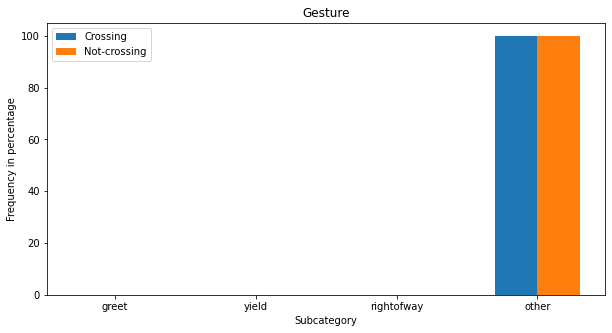

In [19]:
count_pos = {0:0, 1:0, 2:0, 3:0, 4:0}
count_neg = {0:0, 1:0, 2:0, 3:0, 4:0}
count_pos, count_neg = show_categorical_count(raw_df, count_pos, count_neg, category='hand_gesture')
plot_sidebyside_chart(count_pos, count_neg, title='Gesture')

# check reaction

Pos dict: {'__undefined__': 26031, 'clear_path': 0, 'speed_up': 76, 'slow_down': 713}
Neg dict: {'__undefined__': 20750, 'clear_path': 2449, 'speed_up': 0, 'slow_down': 175}


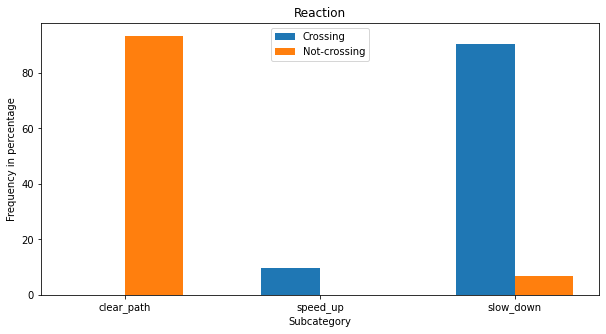

In [20]:
count_pos = {0:0, 1:0, 2:0, 3:0}
count_neg = {0:0, 1:0, 2:0, 3:0}

count_pos, count_neg = show_categorical_count(raw_df, count_pos, count_neg, category='reaction')
plot_sidebyside_chart(count_pos, count_neg, title='Reaction')

# check look

Pos dict: {'not-looking': 17765, 'looking': 9055}
Neg dict: {'not-looking': 16413, 'looking': 6961}


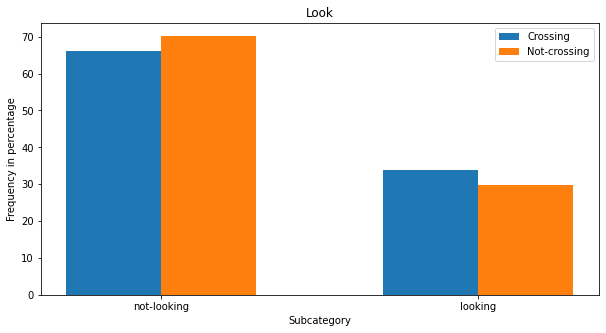

In [21]:
count_pos = {0:0, 1:0}
count_neg = {0:0, 1:0}

count_pos, count_neg = show_categorical_count(raw_df, count_pos, count_neg, category='look')
plot_sidebyside_chart(count_pos, count_neg, title='Look')

# check action

Pos dict: {'standing': 9181, 'walking': 17639}
Neg dict: {'standing': 9454, 'walking': 13920}


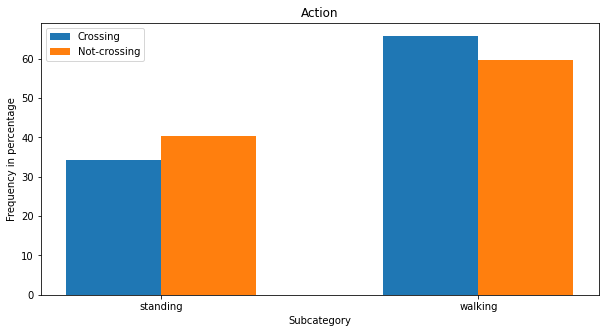

In [22]:
count_pos = {0:0, 1:0}
count_neg = {0:0, 1:0}

count_pos, count_neg = show_categorical_count(raw_df, count_pos, count_neg, category='action')
plot_sidebyside_chart(count_pos, count_neg, title='Action')

# check nod

Pos dict: {'__undefined__': 26768, 'nodding': 52}
Neg dict: {'__undefined__': 23359, 'nodding': 15}


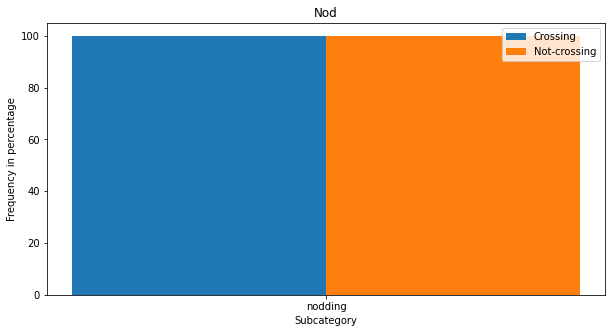

In [23]:
count_pos = {0:0, 1:0}
count_neg = {0:0, 1:0}

count_pos, count_neg = show_categorical_count(raw_df, count_pos, count_neg, category='nod')
plot_sidebyside_chart(count_pos, count_neg, title='Nod')

In [ ]:
#check intersaction
#check vehicle speed


# check vehicle speed

In [ ]:
#                 veh_speed = raw_df[vid]['vehicle_annotations'][frame]
#                 tra_light = raw_df[vid]['traffic_annotations'][frame]['traffic_light']

In [5]:
def update2meaningful_keys(pos_neg_dic, reversed_dic):

    new_data = {}
    
    for k in reversed_dic.keys():
        try:
            new_data[reversed_dic[k]] = pos_neg_dic[k]
        except:
            new_data[reversed_dic[k]] = 0 #some k might have freq 0 in data_array and wasn't counted in collection.Counter
        
    return new_data

In [6]:
def update_count(value_li, dic_count):
    for i in value_li:
        dic_count[i]+=1
    return dic_count

In [7]:
def show_vehspeed_count(raw_df, count_pos, count_neg, explainable_dic):
    reversed_dic = {v: k for k, v in explainable_dic.items()}
    for vid in raw_df.keys():
        ped_data = raw_df[vid]['ped_annotations']
        for ID in ped_data.keys():
            if ID[-1] == 'b':
                cross_li =list(raw_df[vid]['ped_annotations'][ID]['behavior']['cross'])
                veh_dic = raw_df[vid]['vehicle_annotations']
                frames = list(raw_df[vid]['ped_annotations'][ID]['frames'])
                speed_li = []
                if 1 in cross_li:
                    cross_point = cross_li.index(1)
                    cross_frame = frames[cross_point]
                    
                    for frame in frames:
                        if frame<cross_frame:
                            speed=veh_dic[frame]
                            speed_li.append(speed)
                    
                    count_pos = update_count(speed_li, count_pos)

                else:
                    for frame in frames:
                        speed=veh_dic[frame]
                        speed_li.append(speed)
                    count_neg = update_count(speed_li, count_neg)
    
    count_pos = update2meaningful_keys(count_pos, reversed_dic)
    count_neg = update2meaningful_keys(count_neg, reversed_dic)
    print('Pos dict: {0}'.format(count_pos))
    print('Neg dict: {0}'.format(count_neg))
    return count_pos, count_neg

In [160]:
speed_dict = {'stopped': 0, 'moving_slow': 1, 'moving_fast': 2, 'decelerating': 3, 'accelerating': 4}
count_pos = {0:0, 1:0, 2:0, 3:0, 4:0}
count_neg = {0:0, 1:0, 2:0, 3:0, 4:0}
count_pos, count_neg = show_vehspeed_count(raw_df, count_pos, count_neg, explainable_dic=speed_dict)

Pos dict: {'stopped': 3265, 'moving_slow': 1454, 'moving_fast': 1699, 'decelerating': 16403, 'accelerating': 3999}
Neg dict: {'stopped': 1878, 'moving_slow': 1128, 'moving_fast': 994, 'decelerating': 11512, 'accelerating': 7862}


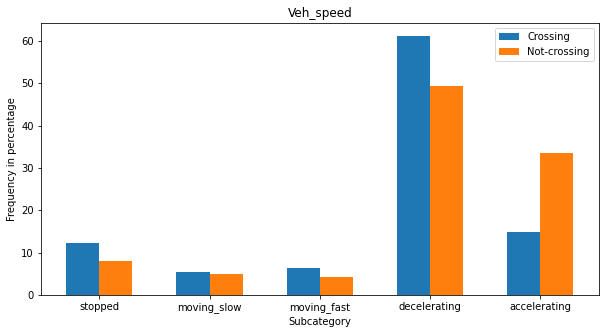

In [8]:
plot_sidebyside_chart(count_pos, count_neg, title='Veh_speed')

# traffic light

In [29]:
# tra_light = raw_df[vid]['traffic_annotations'][frame]['traffic_light']

def show_light_count(raw_df, count_pos, count_neg, explainable_dic):
    reversed_dic = {v: k for k, v in explainable_dic.items()}
    
    for vid in raw_df.keys():
        ped_data = raw_df[vid]['ped_annotations']
        for ID in ped_data.keys():
            if ID[-1] == 'b':
                cross_li =list(raw_df[vid]['ped_annotations'][ID]['behavior']['cross'])
                traffic_dic = raw_df[vid]['traffic_annotations']
                frames = list(raw_df[vid]['ped_annotations'][ID]['frames'])
                light_li = []
                if 1 in cross_li:
                    cross_point = cross_li.index(1)
                    cross_frame = frames[cross_point]
                    
                    for frame in frames:
                        if frame<cross_frame:
                            l=traffic_dic[frame]['traffic_light']
                            light_li.append(l)
                    
                    count_pos = update_count(light_li, count_pos)

                else:
                    for frame in frames:
                        l=traffic_dic[frame]['traffic_light']
                        light_li.append(l)
                    count_neg = update_count(light_li, count_neg)
    
    count_pos = update2meaningful_keys(count_pos, reversed_dic)
    count_neg = update2meaningful_keys(count_neg, reversed_dic)
    print('Pos dict: {0}'.format(count_pos))
    print('Neg dict: {0}'.format(count_neg))
    return count_pos, count_neg

In [35]:
signals = {'n/a': 0, 'red': 1, 'green': 2}
count_pos = {0:0, 1:0, 2:0}
count_neg = {0:0, 1:0, 2:0}
count_pos, count_neg = show_light_count(raw_df, count_pos, count_neg, explainable_dic=signals)

Pos dict: {'n/a': 26001, 'red': 574, 'green': 245}
Neg dict: {'n/a': 21631, 'red': 1308, 'green': 435}


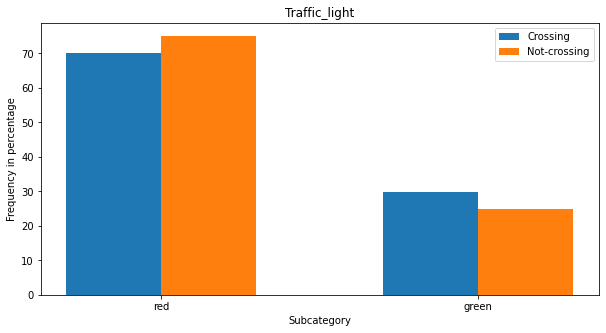

In [36]:
plot_sidebyside_chart(count_pos, count_neg, title='Traffic_light')

# intersection 

In [ ]:
# in the data
#             'look': {0: 'not-looking', 1: 'looking'},
#             'vehicle': {0: 'stopped', 1: 'moving_slow', 2: 'moving_fast',
#                        3: 'decelerating', 4: 'accelerating'},
#             'traffic_light': {0: 'n/a', 1: 'red', 2: 'green'}
#             'reaction': {'__undefined__': 0, 'clear_path': 1, 'speed_up': 2,
#                         'slow_down': 3},

# could be useful
#            'action': {'standing': 0, 'walking': 1},
#            'intersection': {'no': 0, 'yes': 1},
#            'road_type': {'street': 0, 'parking_lot': 1, 'garage': 2},

# controversal
#            'reaction': {'__undefined__': 0, 'clear_path': 1, 'speed_up': 2,
#                         'slow_down': 3},
#            'vehicle': {0: 'stopped', 1: 'moving_slow', 2: 'moving_fast',
#                        3: 'decelerating', 4: 'accelerating'},

In [12]:
#            'designated': {'ND': 0, 'D': 1},
#            'gender': {'n/a': 0, 'female': 1, 'male': 2},

#            'motion_direction': {'n/a': 0, 'LAT': 1, 'LONG': 2},
#            'traffic_direction': {'OW': 0, 'TW': 1},
#            'signalized': {'n/a': 0, 'NS': 1, 'S': 2},

In [42]:
def show_intersection_count(raw_df, count_pos, count_neg, explainable_dic):
    reversed_dic = {v: k for k, v in explainable_dic.items()}
    
    for vid in raw_df.keys():
        ped_data = raw_df[vid]['ped_annotations']
        for ID in ped_data.keys():
            if ID[-1] == 'b':
                cross_li =list(raw_df[vid]['ped_annotations'][ID]['behavior']['cross'])
                inter = raw_df[vid]['ped_annotations'][ID]['attributes']['intersection']
                if 1 in cross_li:
                    count_pos[inter]+=1
                else:
                    count_neg[inter]+=1
    
    count_pos = update2meaningful_keys(count_pos, reversed_dic)
    count_neg = update2meaningful_keys(count_neg, reversed_dic)
    print('Pos dict: {0}'.format(count_pos))
    print('Neg dict: {0}'.format(count_neg))
    return count_pos, count_neg

In [43]:
intersection = {'no': 0, 'yes': 1}
count_pos = {0:0, 1:0}
count_neg = {0:0, 1:0}
count_pos, count_neg = show_intersection_count(raw_df, count_pos, count_neg, explainable_dic=intersection)

Pos dict: {'no': 69, 'yes': 455}
Neg dict: {'no': 93, 'yes': 69}


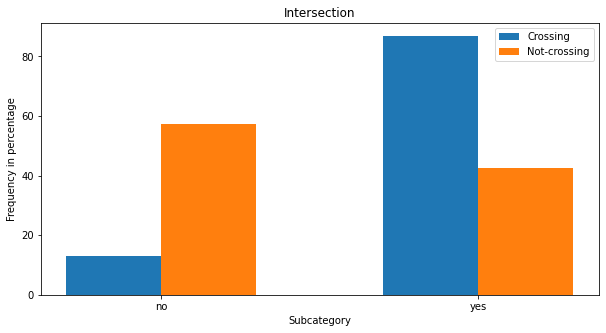

In [44]:
plot_sidebyside_chart(count_pos, count_neg, title='Intersection')

# road type

In [51]:
def show_roadtype_count(raw_df, count_pos, count_neg, explainable_dic):
    reversed_dic = {v: k for k, v in explainable_dic.items()}
    for vid in raw_df.keys():
        ped_data = raw_df[vid]['ped_annotations']
        for ID in ped_data.keys():
            if ID[-1] == 'b':
                cross_li =list(raw_df[vid]['ped_annotations'][ID]['behavior']['cross'])
                road = raw_df[vid]['traffic_annotations']['road_type']
                if 1 in cross_li:
                    count_pos[road]+=1
                else:
                    count_neg[road]+=1
                    
    count_pos = update2meaningful_keys(count_pos, reversed_dic)
    count_neg = update2meaningful_keys(count_neg, reversed_dic)
    print('Pos dict: {0}'.format(count_pos))
    print('Neg dict: {0}'.format(count_neg))
    return count_pos, count_neg

In [52]:
roadtype = {'street': 0, 'parking_lot': 1, 'garage': 2}
count_pos = {0:0, 1:0, 2:0}
count_neg = {0:0, 1:0, 2:0}
count_pos, count_neg= show_roadtype_count(raw_df, count_pos, count_neg, explainable_dic=roadtype)

Pos dict: {'street': 475, 'parking_lot': 47, 'garage': 2}
Neg dict: {'street': 118, 'parking_lot': 44, 'garage': 0}


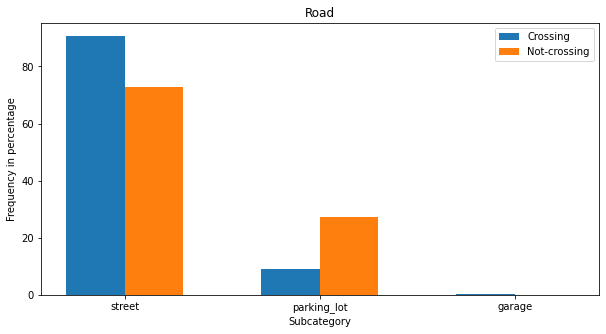

In [53]:
plot_sidebyside_chart(count_pos, count_neg, title='Road')

# pedestrian crossing

In [58]:
def show_light_count(raw_df, count_pos, count_neg, explainable_dic):
    reversed_dic = {v: k for k, v in explainable_dic.items()}
    
    for vid in raw_df.keys():
        ped_data = raw_df[vid]['ped_annotations']
        for ID in ped_data.keys():
            if ID[-1] == 'b':
                cross_li =list(raw_df[vid]['ped_annotations'][ID]['behavior']['cross'])
                traffic_dic = raw_df[vid]['traffic_annotations']
                frames = list(raw_df[vid]['ped_annotations'][ID]['frames'])
                ped_crossingroad_li = []
                if 1 in cross_li:
                    cross_point = cross_li.index(1)
                    cross_frame = frames[cross_point]
                    
                    for frame in frames:
                        if frame<cross_frame:
                            r=traffic_dic[frame]['ped_crossing']
                            ped_crossingroad_li.append(r)
                    
                    count_pos = update_count(ped_crossingroad_li, count_pos)

                else:
                    for frame in frames:
                        r=traffic_dic[frame]['ped_crossing']
                        ped_crossingroad_li.append(r)
                    count_neg = update_count(ped_crossingroad_li, count_neg)
    
    count_pos = update2meaningful_keys(count_pos, reversed_dic)
    count_neg = update2meaningful_keys(count_neg, reversed_dic)
    print('Pos dict: {0}'.format(count_pos))
    print('Neg dict: {0}'.format(count_neg))
    return count_pos, count_neg

In [59]:
raw_df[vid]['traffic_annotations'][0]['ped_crossing']

1

In [69]:
crossingroad = {'No':0, 'Yes':1}
count_pos = {0:0, 1:0}
count_neg = {0:0, 1:0}
count_pos, count_neg = show_light_count(raw_df, count_pos, count_neg, explainable_dic=crossingroad)

Pos dict: {'No': 9331, 'Yes': 17489}
Neg dict: {'No': 16031, 'Yes': 7343}


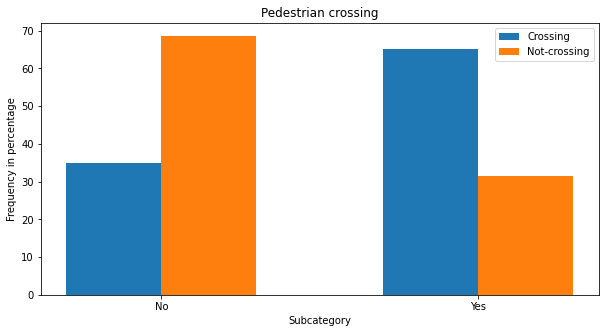

In [70]:
plot_sidebyside_chart(count_pos, count_neg, title='Pedestrian crossing')

In [71]:
new_dic = {}
for vid in raw_df.keys():
    ped_data = raw_df[vid]['ped_annotations']
    for ID in ped_data.keys():
        if ID[-1] == 'b':
            frames = list(raw_df[vid]['ped_annotations'][ID]['frames'])
            traffic_dic = raw_df[vid]['traffic_annotations']
            for f in frames:
                value=traffic_dic[f]['ped_crossing']
                if value not in new_dic.keys():
                    new_dic[value] = 0
                new_dic[value]+=1

In [72]:
new_dic #only two keys in ped_crossing dict 

{0: 54572, 1: 78128}

# Time series analysis on veh speed 

Pos dict: {'stopped': 3265, 'moving_slow': 1454, 'moving_fast': 1699, 'decelerating': 16403, 'accelerating': 3999}
Neg dict: {'stopped': 1878, 'moving_slow': 1128, 'moving_fast': 994, 'decelerating': 11512, 'accelerating': 7862}


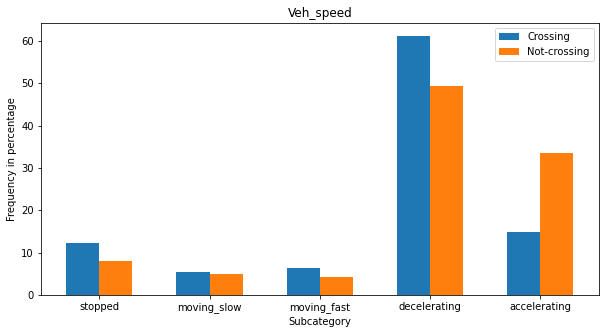

In [8]:
speed_dict = {'stopped': 0, 'moving_slow': 1, 'moving_fast': 2, 'decelerating': 3, 'accelerating': 4}
count_pos = {0:0, 1:0, 2:0, 3:0, 4:0}
count_neg = {0:0, 1:0, 2:0, 3:0, 4:0}
count_pos, count_neg = show_vehspeed_count(raw_df, count_pos, count_neg, explainable_dic=speed_dict)
plot_sidebyside_chart(count_pos, count_neg, title='Veh_speed')

In [28]:
"""
pad empty moment with 5
"""
def preprocess(aggr_li, speed_li, get_small_seq, total_len = 32):
    if len(speed_li)>=total_len:
        speed_li = speed_li[-total_len:]
        aggr_li.append(speed_li)
    else:
        if get_small_seq:
            pad = total_len-len(speed_li)
            pad = np.array([5]*pad).tolist()#not in the dict key == __undefined__
            pad.extend(speed_li)
            aggr_li.append(pad)
        pass
    return aggr_li
        

In [29]:
def get_speed_last32frames(raw_df, pos_li, neg_li, get_small_seq=True):
    for vid in raw_df.keys():
        ped_data = raw_df[vid]['ped_annotations']
        for ID in ped_data.keys():
            if ID[-1] == 'b':
                cross_li =list(raw_df[vid]['ped_annotations'][ID]['behavior']['cross'])
                veh_dic = raw_df[vid]['vehicle_annotations']
                frames = list(raw_df[vid]['ped_annotations'][ID]['frames'])
                speed_li = []
                if 1 in cross_li:
                    cross_point = cross_li.index(1)
                    cross_frame = frames[cross_point]
                    
                    for frame in frames:
                        if frame<cross_frame:
                            speed=veh_dic[frame]
                            speed_li.append(speed)
                    
                    pos_li = preprocess(pos_li, speed_li, get_small_seq , total_len = 32)
                        
                    
                    

                else:
                    for frame in frames:
                        speed=veh_dic[frame]
                        speed_li.append(speed)
                    neg_li = preprocess(neg_li, speed_li, get_small_seq , total_len = 32)
    
    return pos_li, neg_li

In [44]:
pos_li, neg_li = [],[]
pos_li, neg_li = get_speed_last32frames(raw_df, pos_li, neg_li, get_small_seq = True)
pos_li = np.array(pos_li)
neg_li = np.array(neg_li)
print(len(pos_li), len(neg_li))

524 162


In [31]:
# len(pos_li)

In [45]:
import numpy as np

def update_speed_in_frames(aggre_li):
    speed_in_frames = {'stopped': [], 'moving_slow': [], 'moving_fast': [], 'decelerating': [], 'accelerating': []}

    for v in aggre_li:
        stopped_indices = np.where(v == 0)[0].tolist()
        moving_slow_indices = np.where(v == 1)[0].tolist()
        moving_fast_indices = np.where(v == 2)[0].tolist()
        decelerating_indices = np.where(v == 3)[0].tolist()
        accelerating_indices = np.where(v == 4)[0].tolist()
        
        stopped_indices = list(map(str, stopped_indices))
        moving_slow_indices = list(map(str, moving_slow_indices))
        moving_fast_indices = list(map(str, moving_fast_indices))
        decelerating_indices = list(map(str, decelerating_indices))
        accelerating_indices = list(map(str, accelerating_indices))

        speed_in_frames['stopped'].extend(stopped_indices)
        speed_in_frames['moving_slow'].extend(moving_slow_indices)
        speed_in_frames['moving_fast'].extend(moving_fast_indices)
        speed_in_frames['decelerating'].extend(decelerating_indices)
        speed_in_frames['accelerating'].extend(accelerating_indices)
    return speed_in_frames

In [46]:
pos_dic = update_speed_in_frames(pos_li)
neg_dic = update_speed_in_frames(neg_li)


In [47]:
# pos_dic

In [48]:
def plot_sidebyside_chart(data_1, data_2, title, print_freq=False):
    data_1 = drop_na(data_1)
    data_2 = drop_na(data_2)
    keys = list(data_1.keys())
    # Numbers of pairs of bars you want
    N = len(keys)
    # Data on X-axis
    
    blue_freq = list(data_1.values())
    orange_freq = list(data_2.values())
    
    if not print_freq:
        blue_bar = (np.array(blue_freq)/sum(blue_freq))*100
        orange_bar = (np.array(orange_freq)/sum(orange_freq))*100
    else:
        blue_bar = np.array(blue_freq)
        orange_bar = np.array(orange_freq)
        

    # Position of bars on x-axis
    ind = np.arange(N)

    # Figure size
    plt.figure(figsize=(10,5))

    # Width of a bar 
    width = 0.3       

    # Plotting
    plt.bar(ind, blue_bar , width, label='Crossing')
    plt.bar(ind + width, orange_bar, width, label='Not-crossing')

    plt.xlabel('Subcategory')
    plt.ylabel('Frequency in percentage')
    plt.title(title)

    # xticks()
    # First argument - A list of positions at which ticks should be placed
    # Second argument -  A list of labels to place at the given locations
    plt.xticks(ind + width / 2, [k for k in keys])

    # Finding the best position for legends and putting it
    plt.legend(loc='best')
    plt.show()

In [49]:
def swap_keys_to_tte(new_data, time_li, max_time):
    """
    swap to int to calculate tte
    """
    time_li = np.array(time_li).astype(int)
    tte = max_time - time_li
    """
    swap back to str to update dictionary
    """
    update_new_data = {}
    for i, t in enumerate(time_li):
        
        update_new_data[str(tte[i])] = new_data.pop(str(t))
    return update_new_data
    

In [50]:
def count(speed_dic, cat, max_time=32):
    time_li=[str(i) for i in range(max_time)]
    data = collections.Counter(speed_dic[cat])
    data = dict(data)
    new_data = {}
    
    for t in time_li:
        if t not in data.keys():
            data[t] = 0
    for t in time_li:
        new_data[t] = data[t]
        
    new_data = swap_keys_to_tte(new_data, time_li, max_time)

    return new_data

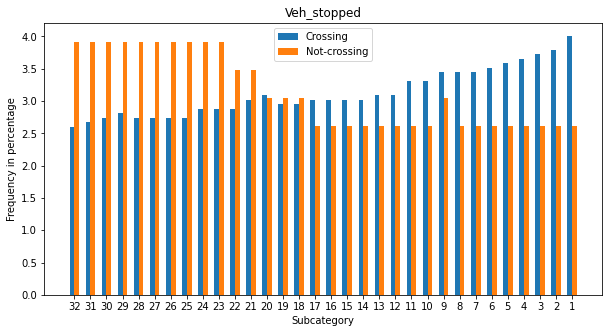

In [51]:
import collections
count_pos = count(speed_dic=pos_dic, cat='stopped')
count_neg = count(speed_dic=neg_dic, cat='stopped')
plot_sidebyside_chart(count_pos, count_neg, title='Veh_stopped')

In [52]:
# neg_dic['moving_slow']
# count_neg

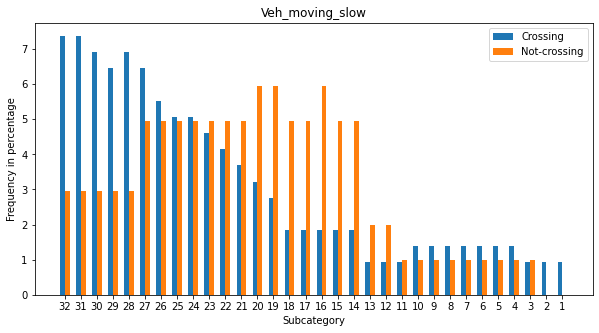

In [53]:
# cat = 'moving_slow'
count_pos = count(speed_dic=pos_dic, cat='moving_slow')
count_neg = count(speed_dic=neg_dic, cat='moving_slow')
plot_sidebyside_chart(count_pos, count_neg, title='Veh_moving_slow')

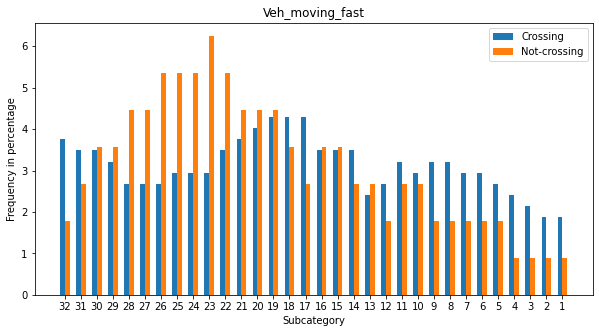

In [54]:
count_pos = count(speed_dic=pos_dic, cat='moving_fast')
count_neg = count(speed_dic=neg_dic, cat='moving_fast')
plot_sidebyside_chart(count_pos, count_neg, title='Veh_moving_fast')

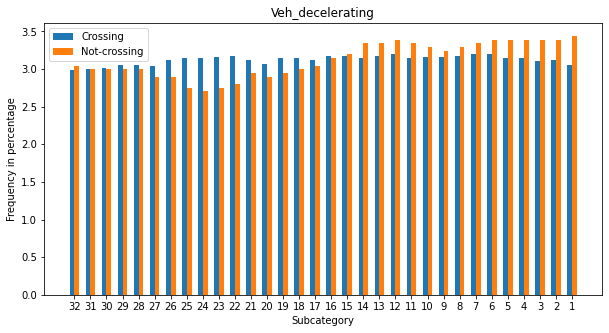

In [55]:
count_pos = count(speed_dic=pos_dic, cat='decelerating')
count_neg = count(speed_dic=neg_dic, cat='decelerating')
plot_sidebyside_chart(count_pos, count_neg, title='Veh_decelerating')

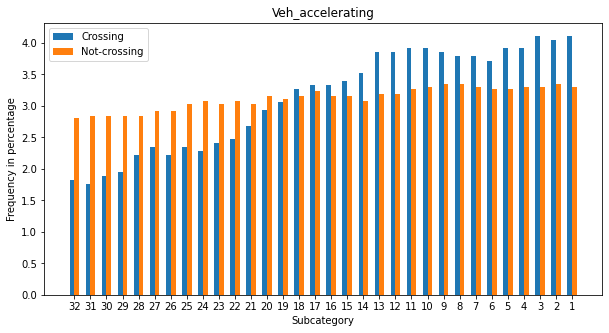

In [56]:
count_pos = count(speed_dic=pos_dic, cat='accelerating')
count_neg = count(speed_dic=neg_dic, cat='accelerating')
plot_sidebyside_chart(count_pos, count_neg, title='Veh_accelerating')

In [68]:
import numpy as np
raw_global_env = [[0, 2]]
# print(raw_global_env.shape)
# np.array([[0,1]]*2).shape

In [69]:
li = [raw_global_env*2, raw_global_env*5]
data_pos_g = np.concatenate(li, axis=0)
print(data_pos_g.shape)

(7, 2)
